<a href="https://www.kaggle.com/code/lalit7881/airport-traffic-2026-eda?scriptVersionId=312976380" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nilesh2042/airport-traffic-dataset/airport_traffic_2025.csv
/kaggle/input/datasets/nilesh2042/airport-traffic-dataset/airport_traffic_2026.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/nilesh2042/airport-traffic-dataset/airport_traffic_2026.csv")

In [3]:
df.head()

,YEAR,MONTH_NUM,MONTH_MON,FLT_DATE,APT_ICAO,APT_NAME,STATE_NAME,FLT_DEP_1,FLT_ARR_1,FLT_TOT_1,FLT_DEP_IFR_2,FLT_ARR_IFR_2,FLT_TOT_IFR_2
0,2026,1,JAN,2026-01-01,LATI,Tirana,Albania,67,70,137,NaN,NaN,NaN
1,2026,1,JAN,2026-01-01,UDYZ,Yerevan,Armenia,54,55,109,NaN,NaN,NaN
2,2026,1,JAN,2026-01-01,LOWG,Graz,Austria,7,6,13,NaN,NaN,NaN
3,2026,1,JAN,2026-01-01,LOWI,Innsbruck,Austria,21,23,44,NaN,NaN,NaN
4,2026,1,JAN,2026-01-01,LOWK,Klagenfurt,Austria,5,2,7,NaN,NaN,NaN


In [4]:
df.tail()

,YEAR,MONTH_NUM,MONTH_MON,FLT_DATE,APT_ICAO,APT_NAME,STATE_NAME,FLT_DEP_1,FLT_ARR_1,FLT_TOT_1,FLT_DEP_IFR_2,FLT_ARR_IFR_2,FLT_TOT_IFR_2
9746,2026,1,JAN,2026-01-31,EGNX,East Midlands,United Kingdom,45,42,87,NaN,NaN,NaN
9747,2026,1,JAN,2026-01-31,EGPD,Aberdeen,United Kingdom,23,22,45,NaN,NaN,NaN
9748,2026,1,JAN,2026-01-31,EGPF,Glasgow,United Kingdom,67,72,139,NaN,NaN,NaN
9749,2026,1,JAN,2026-01-31,EGPH,Edinburgh,United Kingdom,117,117,234,117.0,117.0,234.0
9750,2026,1,JAN,2026-01-31,EGSS,London - Stansted,United Kingdom,238,237,475,239.0,237.0,476.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9751 entries, 0 to 9750
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   YEAR           9751 non-null   int64  
 1   MONTH_NUM      9751 non-null   int64  
 2   MONTH_MON      9751 non-null   object 
 3   FLT_DATE       9751 non-null   object 
 4   APT_ICAO       9751 non-null   object 
 5   APT_NAME       9751 non-null   object 
 6   STATE_NAME     9751 non-null   object 
 7   FLT_DEP_1      9751 non-null   int64  
 8   FLT_ARR_1      9751 non-null   int64  
 9   FLT_TOT_1      9751 non-null   int64  
 10  FLT_DEP_IFR_2  1860 non-null   float64
 11  FLT_ARR_IFR_2  1860 non-null   float64
 12  FLT_TOT_IFR_2  1860 non-null   float64
dtypes: float64(3), int64(5), object(5)
memory usage: 990.5+ KB


In [6]:
df.describe()

,YEAR,MONTH_NUM,FLT_DEP_1,FLT_ARR_1,FLT_TOT_1,FLT_DEP_IFR_2,FLT_ARR_IFR_2,FLT_TOT_IFR_2
count,9751.0,9751.0,9751.000000,9751.000000,9751.000000,1860.000000,1860.000000,1860.000000
mean,2026.0,1.0,60.019690,60.030048,120.049738,165.180645,165.070968,330.251613
std,0.0,0.0,106.086172,105.988920,212.042302,144.027415,143.754880,287.685702
min,2026.0,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2026.0,1.0,4.000000,4.000000,8.000000,59.000000,58.000000,118.750000
50%,2026.0,1.0,15.000000,15.000000,31.000000,117.000000,116.000000,233.500000
75%,2026.0,1.0,68.000000,68.000000,136.000000,242.000000,243.000000,484.000000
max,2026.0,1.0,766.000000,771.000000,1527.000000,668.000000,660.000000,1324.000000


In [7]:
df.isnull().sum()

YEAR                0
MONTH_NUM           0
MONTH_MON           0
FLT_DATE            0
APT_ICAO            0
APT_NAME            0
STATE_NAME          0
FLT_DEP_1           0
FLT_ARR_1           0
FLT_TOT_1           0
FLT_DEP_IFR_2    7891
FLT_ARR_IFR_2    7891
FLT_TOT_IFR_2    7891
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

YEAR               int64
MONTH_NUM          int64
MONTH_MON         object
FLT_DATE          object
APT_ICAO          object
APT_NAME          object
STATE_NAME        object
FLT_DEP_1          int64
FLT_ARR_1          int64
FLT_TOT_1          int64
FLT_DEP_IFR_2    float64
FLT_ARR_IFR_2    float64
FLT_TOT_IFR_2    float64
dtype: object

In [10]:
df.shape

(9751, 13)

In [11]:
df.columns

Index(['YEAR', 'MONTH_NUM', 'MONTH_MON', 'FLT_DATE', 'APT_ICAO', 'APT_NAME',
       'STATE_NAME', 'FLT_DEP_1', 'FLT_ARR_1', 'FLT_TOT_1', 'FLT_DEP_IFR_2',
       'FLT_ARR_IFR_2', 'FLT_TOT_IFR_2'],
      dtype='object')

In [12]:
df.nunique()

YEAR               1
MONTH_NUM          1
MONTH_MON          1
FLT_DATE          31
APT_ICAO         330
APT_NAME         330
STATE_NAME        42
FLT_DEP_1        532
FLT_ARR_1        527
FLT_TOT_1        864
FLT_DEP_IFR_2    462
FLT_ARR_IFR_2    451
FLT_TOT_IFR_2    732
dtype: int64

## EDA

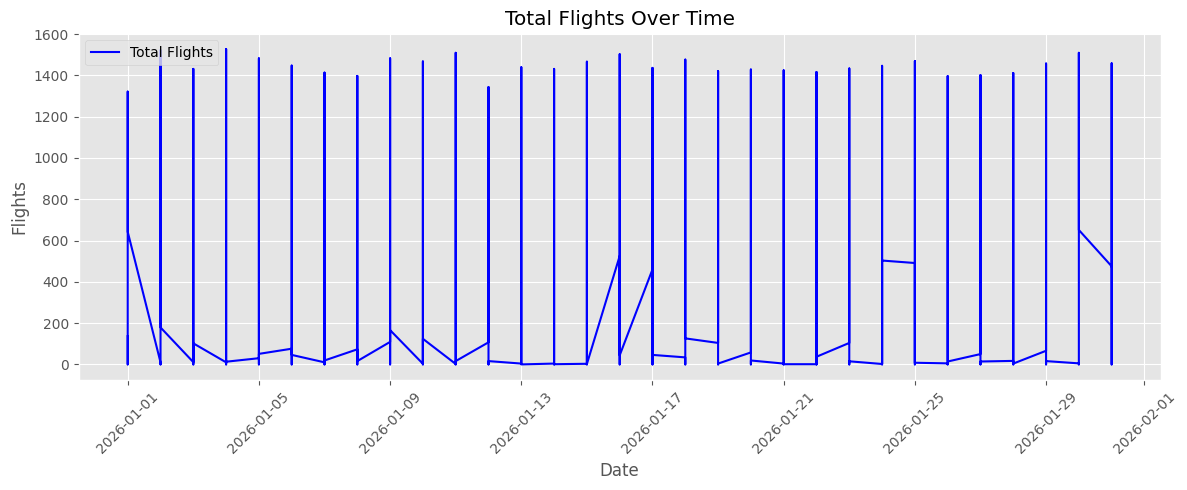

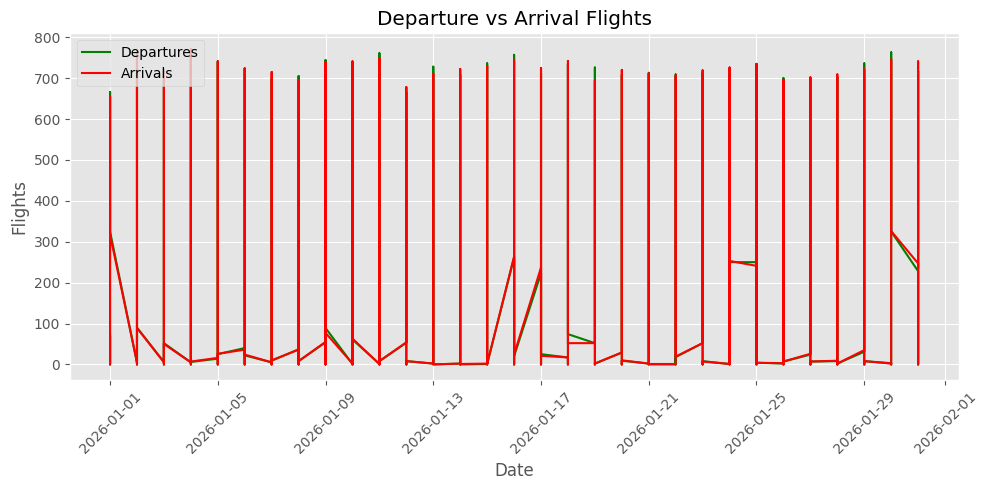

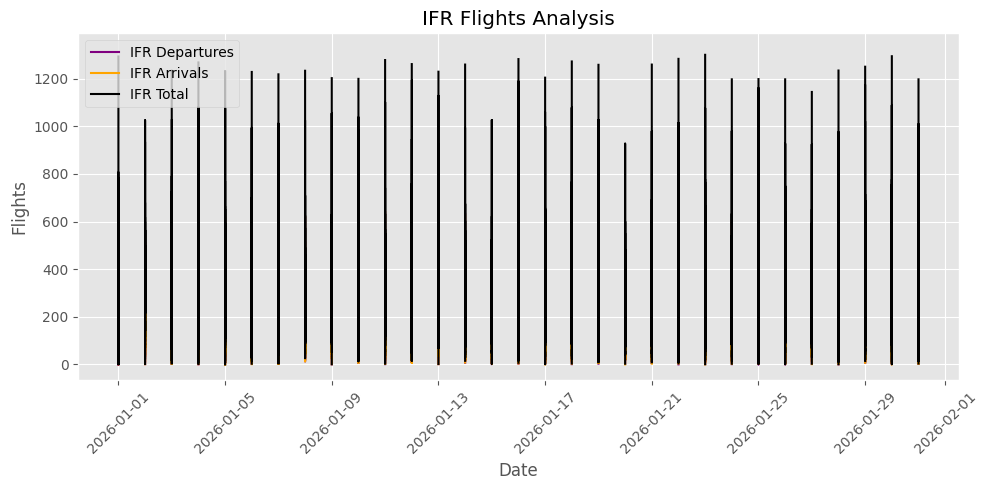

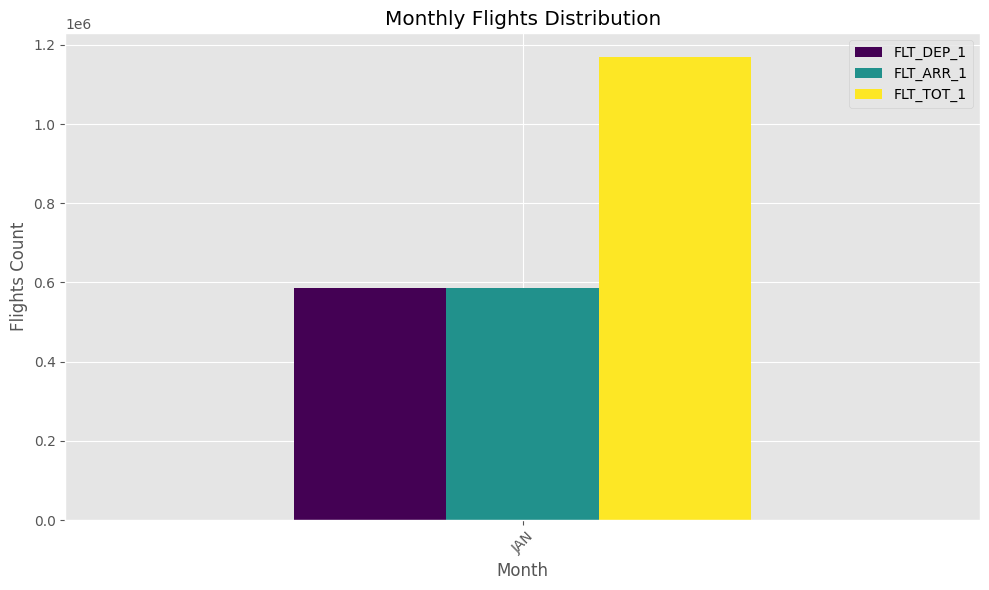

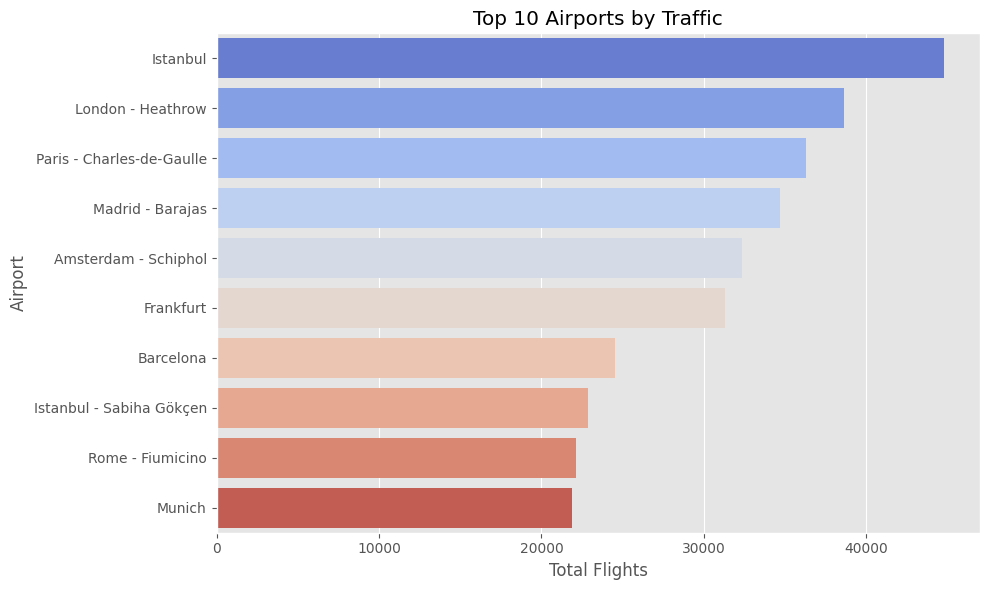

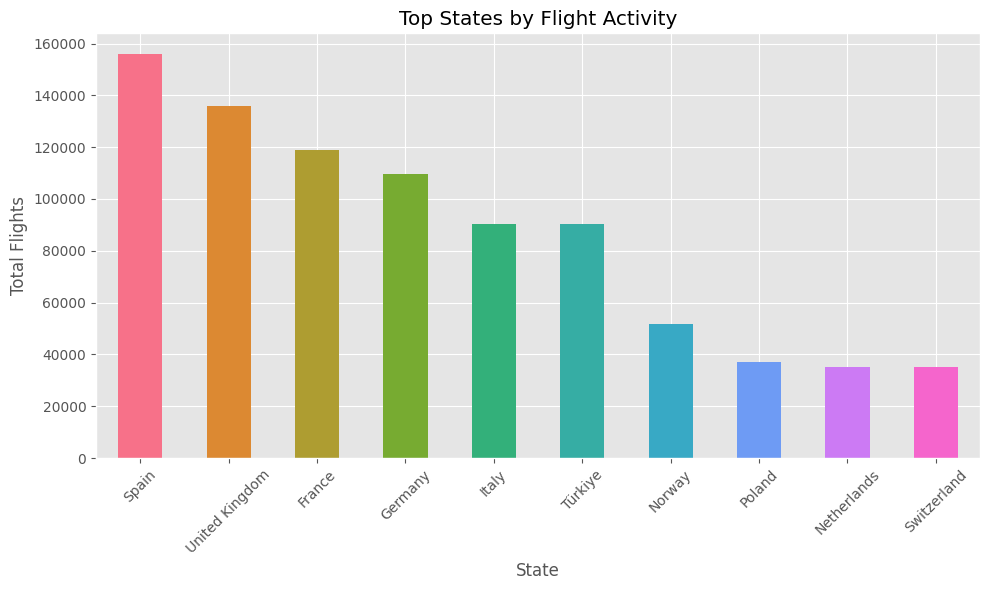

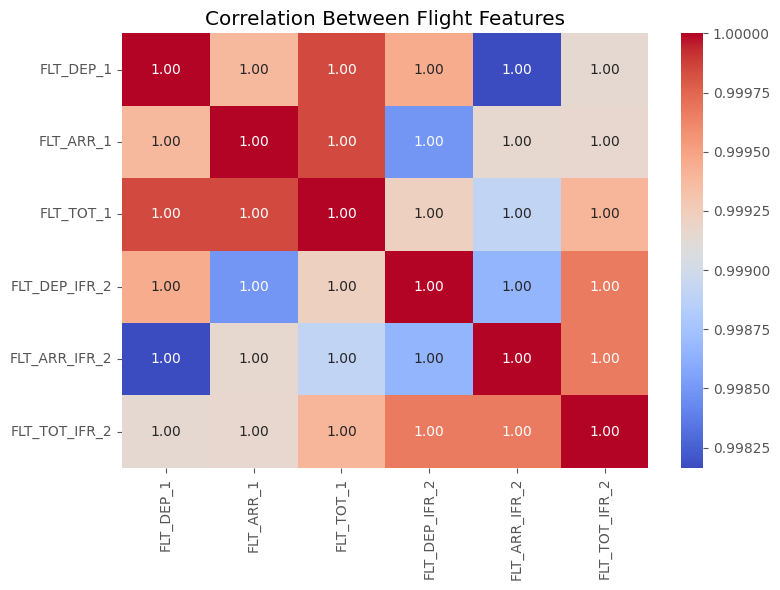

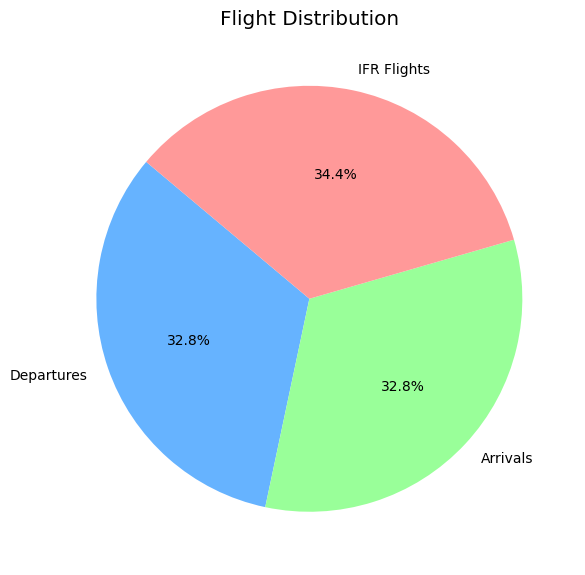

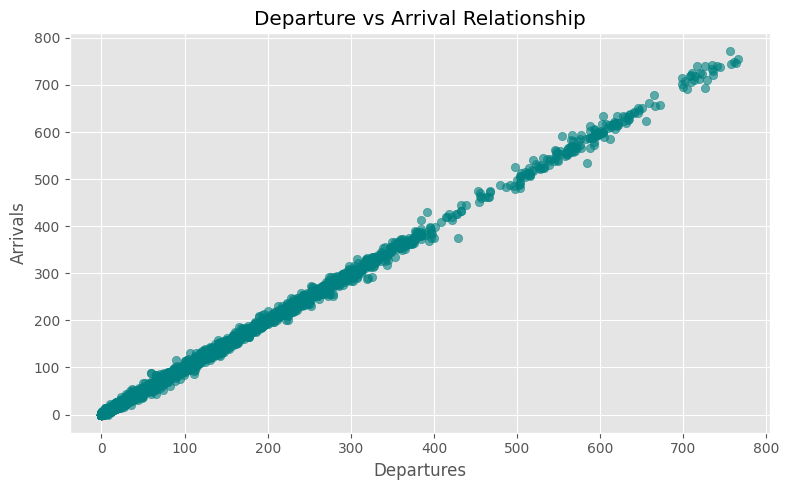

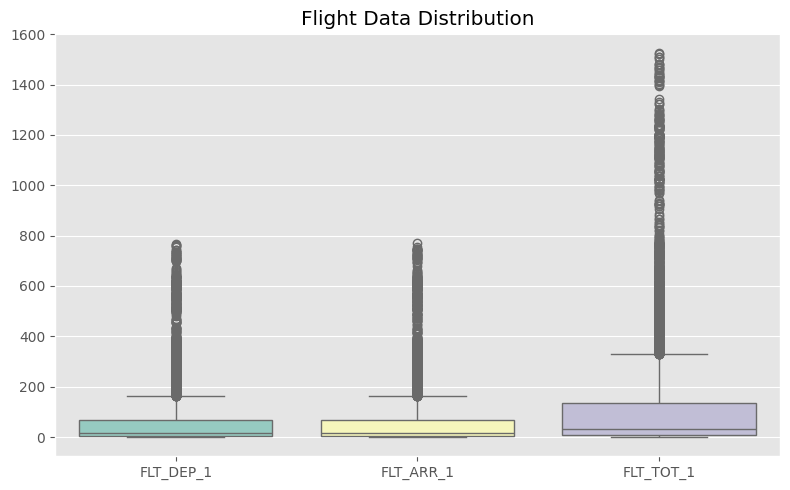

In [13]:

# Style
plt.style.use('ggplot')
sns.set_palette("Set2")

# ==============================
# DATA PREPROCESSING
# ==============================
# Convert date
df['FLT_DATE'] = pd.to_datetime(df['FLT_DATE'], errors='coerce')

# Sort values
df = df.sort_values(by='FLT_DATE')

# ==============================
# 1. TOTAL FLIGHTS OVER TIME
# ==============================
plt.figure(figsize=(12,5))
plt.plot(df['FLT_DATE'], df['FLT_TOT_1'], color='blue', label='Total Flights')
plt.title('Total Flights Over Time')
plt.xlabel('Date')
plt.ylabel('Flights')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ==============================
# 2. DEPARTURE vs ARRIVAL
# ==============================
plt.figure(figsize=(10,5))
plt.plot(df['FLT_DATE'], df['FLT_DEP_1'], color='green', label='Departures')
plt.plot(df['FLT_DATE'], df['FLT_ARR_1'], color='red', label='Arrivals')
plt.title('Departure vs Arrival Flights')
plt.xlabel('Date')
plt.ylabel('Flights')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ==============================
# 3. IFR FLIGHTS COMPARISON
# ==============================
plt.figure(figsize=(10,5))
plt.plot(df['FLT_DATE'], df['FLT_DEP_IFR_2'], color='purple', label='IFR Departures')
plt.plot(df['FLT_DATE'], df['FLT_ARR_IFR_2'], color='orange', label='IFR Arrivals')
plt.plot(df['FLT_DATE'], df['FLT_TOT_IFR_2'], color='black', label='IFR Total')
plt.title('IFR Flights Analysis')
plt.xlabel('Date')
plt.ylabel('Flights')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ==============================
# 4. MONTHLY FLIGHT ANALYSIS
# ==============================
monthly = df.groupby('MONTH_MON')[['FLT_DEP_1','FLT_ARR_1','FLT_TOT_1']].sum()

monthly.plot(kind='bar', figsize=(10,6), colormap='viridis')
plt.title('Monthly Flights Distribution')
plt.xlabel('Month')
plt.ylabel('Flights Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ==============================
# 5. TOP AIRPORTS BY TRAFFIC
# ==============================
top_airports = df.groupby('APT_NAME')['FLT_TOT_1'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_airports.values, y=top_airports.index, palette='coolwarm')
plt.title('Top 10 Airports by Traffic')
plt.xlabel('Total Flights')
plt.ylabel('Airport')
plt.tight_layout()
plt.show()

# ==============================
# 6. STATE WISE FLIGHTS
# ==============================
state_data = df.groupby('STATE_NAME')['FLT_TOT_1'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
state_data.plot(kind='bar', color=sns.color_palette("husl", len(state_data)))
plt.title('Top States by Flight Activity')
plt.xlabel('State')
plt.ylabel('Total Flights')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ==============================
# 7. HEATMAP (CORRELATION)
# ==============================
plt.figure(figsize=(8,6))
corr = df[['FLT_DEP_1','FLT_ARR_1','FLT_TOT_1',
           'FLT_DEP_IFR_2','FLT_ARR_IFR_2','FLT_TOT_IFR_2']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Between Flight Features')
plt.tight_layout()
plt.show()

# ==============================
# 8. PIE CHART (FLIGHT DISTRIBUTION)
# ==============================
totals = [
    df['FLT_DEP_1'].sum(),
    df['FLT_ARR_1'].sum(),
    df['FLT_TOT_IFR_2'].sum()
]

labels = ['Departures', 'Arrivals', 'IFR Flights']
colors = ['#66b3ff','#99ff99','#ff9999']

plt.figure(figsize=(6,6))
plt.pie(totals, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140)
plt.title('Flight Distribution')
plt.tight_layout()
plt.show()

# ==============================
# 9. SCATTER PLOT (DEP vs ARR)
# ==============================
plt.figure(figsize=(8,5))
plt.scatter(df['FLT_DEP_1'], df['FLT_ARR_1'], color='teal', alpha=0.6)
plt.title('Departure vs Arrival Relationship')
plt.xlabel('Departures')
plt.ylabel('Arrivals')
plt.tight_layout()
plt.show()

# ==============================
# 10. BOXPLOT (OUTLIERS)
# ==============================
plt.figure(figsize=(8,5))
sns.boxplot(data=df[['FLT_DEP_1','FLT_ARR_1','FLT_TOT_1']], palette='Set3')
plt.title('Flight Data Distribution')
plt.tight_layout()
plt.show()

## Feture engineering


Logistic Regression Accuracy: 0.9836

Logistic Regression Confusion Matrix:
 [[975   6]
 [ 26 944]]

Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       981
           1       0.99      0.97      0.98       970

    accuracy                           0.98      1951
   macro avg       0.98      0.98      0.98      1951
weighted avg       0.98      0.98      0.98      1951


Decision Tree Accuracy: 1.0000

Decision Tree Confusion Matrix:
 [[981   0]
 [  0 970]]

Decision Tree Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       981
           1       1.00      1.00      1.00       970

    accuracy                           1.00      1951
   macro avg       1.00      1.00      1.00      1951
weighted avg       1.00      1.00      1.00      1951


Random Forest Accuracy: 1.0000

Random Forest Confusion Matrix:
 [[981   0]
 [  0 970]]

Random Fores

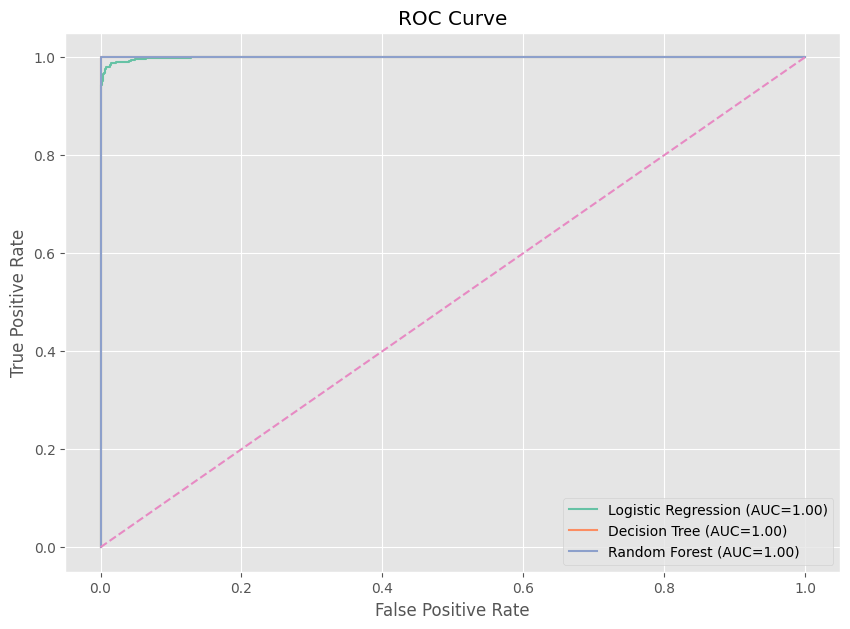

In [14]:
# =========================================
# IMPORT LIBRARIES
# =========================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, auc
)
# =========================================
# PREPROCESSING
# =========================================
df['FLT_DATE'] = pd.to_datetime(df['FLT_DATE'], errors='coerce')

# =========================================
# TARGET CREATION
# =========================================
median_val = df['FLT_TOT_1'].median()
df['HIGH_TRAFFIC'] = (df['FLT_TOT_1'] > median_val).astype(int)

# =========================================
# FEATURES
# =========================================
X = df.drop(columns=['HIGH_TRAFFIC', 'FLT_DATE'])
y = df['HIGH_TRAFFIC']

categorical_cols = ['MONTH_MON', 'APT_ICAO', 'APT_NAME', 'STATE_NAME']
numeric_cols = [col for col in X.columns if col not in categorical_cols]

# =========================================
# TRAIN TEST SPLIT
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================================
# PIPELINES WITH IMPUTATION
# =========================================

# Numeric pipeline
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),   # 🔥 FIX
    ('scaler', StandardScaler())
])

# Categorical pipeline
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # 🔥 FIX
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

# =========================================
# MODELS
# =========================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

# =========================================
# TRAIN + EVALUATION
# =========================================
plt.figure(figsize=(10,7))

for name, model in models.items():

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name} Accuracy: {acc:.4f}")

    # Confusion Matrix
    print(f"\n{name} Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    # Classification Report
    print(f"\n{name} Report:\n", classification_report(y_test, y_pred))

    # =========================================
    # ROC CURVE
    # =========================================
    if hasattr(model, "predict_proba"):
        y_prob = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_prob = pipeline.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

# Final ROC Plot
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Thank you..pls upvote!!!!!!!!!!!